In [38]:
!pip install pandas numpy tensorflow keras-tuner sentence-transformers matplotlib


In [39]:
import pandas as pd
import numpy as np
import json
import ast
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout, Multiply, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import kerastuner as kt
from sklearn.model_selection import KFold

In [40]:
import keras_tuner as kt

## Function to parse a feature vector from a string

In [41]:
def parse_vector(feature_str):
    if not isinstance(feature_str, str):
        try:
            return np.array(feature_str, dtype=float)
        except Exception as e:
            print("Error converting non-string to array:", e)
            return np.zeros(1)

    cleaned_str = feature_str.replace('\n', ' ').strip()

    if not (cleaned_str.startswith('[') and cleaned_str.endswith(']')):
        print("Invalid format (missing brackets):", cleaned_str)
        return np.zeros(1)

    # If commas are present, try JSON or ast.literal_eval first
    if ',' in cleaned_str:
        fixed_str = cleaned_str.replace("'", '"')
        try:
            vec = json.loads(fixed_str)
            return np.array(vec, dtype=float)
        except Exception as e_json:
            print("JSON parsing error:", e_json)

        try:
            vec = ast.literal_eval(cleaned_str)
            return np.array(vec, dtype=float)
        except Exception as e_ast:
            print("ast.literal_eval error:", e_ast)

    # Fallback: assume values are whitespace-separated
    try:
        inner_str = cleaned_str[1:-1].strip()
        parts = inner_str.split()
        vec = [float(part) for part in parts]
        return np.array(vec, dtype=float)
    except Exception as e_manual:
        print("Manual fix error:", e_manual)
        return np.zeros(1)



In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(10, activation='relu', input_shape=(10,)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

x_dummy = np.random.rand(100, 10).astype(np.float32)
y_dummy = np.random.rand(100).astype(np.float32)

model.fit(x_dummy, y_dummy, epochs=1, batch_size=32)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3326 


In [43]:
df = pd.read_csv('master_dataset_for_training.csv')
print("Dataset loaded. Total records:", len(df))


Dataset loaded. Total records: 301


In [44]:
# Parse text embeddings and structured features
df['text_embedding_parsed'] = df['transcript_embedding'].apply(parse_vector)
df['structured_features_parsed'] = df['structured_features'].apply(parse_vector)


In [45]:
example_text_embed = df['text_embedding_parsed'].iloc[0]
example_struct_embed = df['structured_features_parsed'].iloc[0]
print("Example text embedding shape:", example_text_embed.shape)
print("Example structured feature vector shape:", example_struct_embed.shape)

Example text embedding shape: (384,)
Example structured feature vector shape: (42,)


## 2. Build Feature Matrices and Target Vector

In [46]:
X_text = np.vstack(df['text_embedding_parsed'].values)
X_struct = np.vstack(df['structured_features_parsed'].values)

In [47]:
df['Overall_Score'] = df['Overall_Score'].astype(float)
y = df['Overall_Score'].values

In [48]:

# Validate data
assert not np.any(np.isnan(X_text)), "NaN values in X_text"
assert not np.any(np.isinf(X_text)), "Infinite values in X_text"
assert not np.any(np.isnan(X_struct)), "NaN values in X_struct"
assert not np.any(np.isinf(X_struct)), "Infinite values in X_struct"
assert not np.any(np.isnan(y)), "NaN values in y"
assert not np.any(np.isinf(y)), "Infinite values in y"

print("X_text shape:", X_text.shape)
print("X_struct shape:", X_struct.shape)
print("Target shape:", y.shape)

X_text shape: (301, 384)
X_struct shape: (301, 42)
Target shape: (301,)


## 3. Split Data into Training, Validation, and Test Sets

In [49]:
X_text_train, X_text_temp, X_struct_train, X_struct_temp, y_train, y_temp = train_test_split(
    X_text, X_struct, y, test_size=0.3, random_state=42)
X_text_val, X_text_test, X_struct_val, X_struct_test, y_val, y_test = train_test_split(
    X_text_temp, X_struct_temp, y_temp, test_size=0.5, random_state=42)

print("Training set shape (text):", X_text_train.shape)
print("Validation set shape (text):", X_text_val.shape)
print("Test set shape (text):", X_text_test.shape)

Training set shape (text): (210, 384)
Validation set shape (text): (45, 384)
Test set shape (text): (46, 384)


 ## 4. Build the Multi-Modal Fusion Model with Hyperparameter Tuning

 - a gating mechanism is used to fuse the mdoalities
 - text and structured inputs are projected into a common dimension
 - a learned gate is computed to weight the mdoality, and fused and then a prediction head is added
 - keras tuner is used to search for best hyperparameters

In [50]:
def build_fusion_model(hp):
    # Input layers
    text_input = Input(shape=(X_text_train.shape[1],), name='text_input')
    structured_input = Input(shape=(X_struct_train.shape[1],), name='structured_input')

    # Project text input to a common dimension (hp_int units)
    proj_dim = hp.Int('proj_dim', min_value=32, max_value=64, step=32)
    text_proj = Dense(proj_dim, activation='relu', name='text_projection')(text_input)

    # Project structured input to the same dimension
    struct_proj = Dense(proj_dim, activation='relu', name='struct_projection')(structured_input)

    # Fusion via gating: compute a gate value from concatenated projected features
    concat_proj = Concatenate(name='concat_proj')([text_proj, struct_proj])
    gate = Dense(proj_dim, activation='sigmoid', name='fusion_gate')(concat_proj)
    # Compute fused representation as weighted sum of projections:
    fused = Add(name='fused')([
        Multiply()([text_proj, gate]),
        Multiply()([struct_proj, 1 - gate])
    ])

    # Further processing: fusion dense layers
    fusion_units = hp.Int('fusion_units', min_value=32, max_value=64, step=32)
    x = Dense(fusion_units, activation='relu', name='fusion_dense')(fused)
    dropout_rate = hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1)
    x = Dropout(dropout_rate, name='fusion_dropout')(x)

    # Prediction head: output one value (regression)
    output = Dense(1, activation='linear', name='overall_score_output')(x)

    model = Model(inputs=[text_input, structured_input], outputs=output)

    # Optimizer learning rate tuning
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error', metrics=['mae'])

    return model

 ## 5. Set Up Keras Tuner for Hyperparameter Search

In [51]:
tuner = kt.RandomSearch(
    build_fusion_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=2,
    directory='fusion_tuner',
    project_name='candidate_fusion_model'
)

Reloading Tuner from fusion_tuner/candidate_fusion_model/tuner0.json


In [52]:
train_inputs = {'text_input': X_text_train, 'structured_input': X_struct_train}

In [53]:
# Early stopping callback to prevent overfitting.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Start hyperparameter search (use small batch_size and fewer epochs for testing)
tuner.search(train_inputs, y_train, epochs=10, batch_size=2,
             validation_data=({'text_input': X_text_val, 'structured_input': X_struct_val}, y_val),
             callbacks=[early_stop])

## 6. Retrieve and Evaluate the Best Model

In [54]:

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:", best_hp.values)


Best Hyperparameters: {'proj_dim': 64, 'fusion_units': 64, 'dropout_rate': 0.0, 'learning_rate': 0.0005278912278510517}


In [55]:

best_model = tuner.hypermodel.build(best_hp)
# Train the best model on the combined training+validation set if desired,
# or simply evaluate on the held-out test set.
test_inputs = {'text_input': X_text_test, 'structured_input': X_struct_test}
test_loss, test_mae = best_model.evaluate(test_inputs, y_test)
print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7255 - mae: 0.8274 
Test Loss (MSE): 0.7343761324882507
Test MAE: 0.8320390582084656


In [56]:

y_test_pred = best_model.predict(test_inputs).flatten()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


## 7. Visualize Predictions

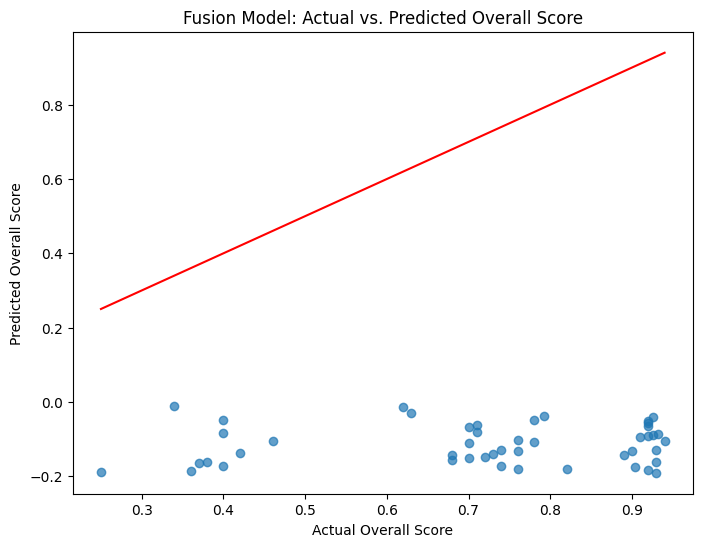

In [57]:

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("Actual Overall Score")
plt.ylabel("Predicted Overall Score")
plt.title("Fusion Model: Actual vs. Predicted Overall Score")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # reference diagonal
plt.show()

## K-fold cross validation on a new fusion model
- 5 fold cross validation

In [58]:
def build_fusion_model(hp):
    # Input layers
    text_input = Input(shape=(X_text.shape[1],), name='text_input')
    structured_input = Input(shape=(X_struct.shape[1],), name='structured_input')

    # Project text input to a common dimension
    proj_dim = hp.Int('proj_dim', min_value=32, max_value=128, step=32)
    text_proj = Dense(proj_dim, activation='relu', name='text_projection')(text_input)

    # Project structured input to the same dimension
    struct_proj = Dense(proj_dim, activation='relu', name='struct_projection')(structured_input)

    # Fusion via gating:
    concat_proj = Concatenate(name='concat_proj')([text_proj, struct_proj])
    gate = Dense(proj_dim, activation='sigmoid', name='fusion_gate')(concat_proj)

    # Fuse: weighted sum of text_proj and structured_proj via gate
    fused = Add(name='fused')([
        Multiply(name='text_weight')([text_proj, gate]),
        Multiply(name='struct_weight')([struct_proj, 1 - gate])
    ])

    # Fusion dense layers
    fusion_units = hp.Int('fusion_units', min_value=32, max_value=128, step=32)
    x = Dense(fusion_units, activation='relu', name='fusion_dense')(fused)
    dropout_rate = hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1)
    x = Dropout(dropout_rate, name='fusion_dropout')(x)

    # Prediction head: output one value (regression)
    output = Dense(1, activation='linear', name='overall_score_output')(x)

    model = Model(inputs=[text_input, structured_input], outputs=output)

    # Learning rate tuning
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error', metrics=['mae'])
    return model

In [59]:
# Define a function to plot learning curves from a Keras History object.
def plot_learning_curves(history, fold):
    epochs = range(1, len(history.history['loss']) + 1)
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], 'bo-', label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], 'ro-', label='Val Loss')
    plt.title(f'Fold {fold} - Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()

    # Plot MAE if available
    if 'mae' in history.history and 'val_mae' in history.history:
        plt.subplot(1, 2, 2)
        plt.plot(epochs, history.history['mae'], 'bo-', label='Train MAE')
        plt.plot(epochs, history.history['val_mae'], 'ro-', label='Val MAE')
        plt.title(f'Fold {fold} - MAE over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MAE')
        plt.legend()

    plt.tight_layout()
    plt.show()


In [60]:
# Prepare lists to store metrics across folds
rmse_list = []
mae_list = []
mse_list = []
r2_list = []
fold = 1

# For visualization, we collect actual and predicted values across folds
all_actual = []
all_pred = []

# kfold for cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

Training fold 1 ...
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.3980 - mae: 0.5615 - val_loss: 0.0443 - val_mae: 0.1727
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0366 - mae: 0.1557 - val_loss: 0.0194 - val_mae: 0.1147
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0129 - mae: 0.0953 - val_loss: 0.0091 - val_mae: 0.0754
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0073 - mae: 0.0669 - val_loss: 0.0068 - val_mae: 0.0652
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0061 - mae: 0.0595 - val_loss: 0.0058 - val_mae: 0.0593
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - mae: 0.0532 - val_loss: 0.0054 - val_mae: 0.0546
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0067 - mae: 0.0611 - val_loss: 0.0054 - val_mae: 0.0541
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 - mae: 0.0494 - val_loss: 0.0051 - val_mae: 0.0525
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step -

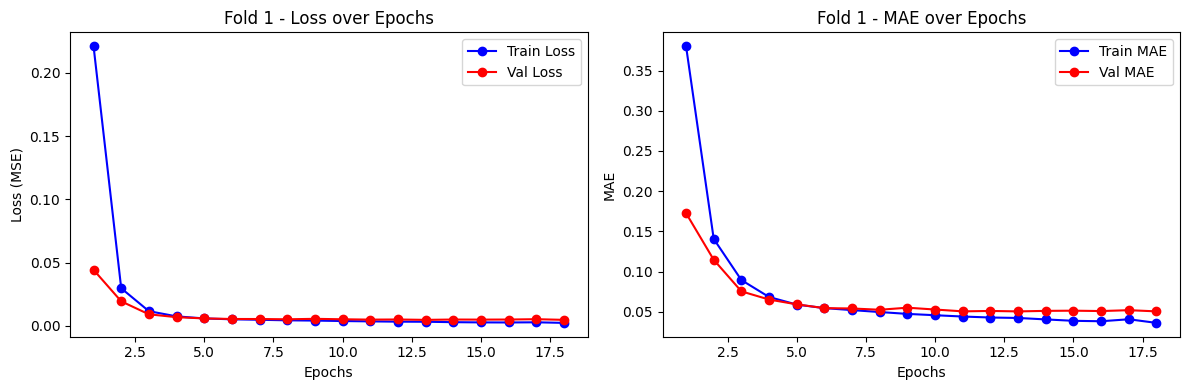

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Fold 1 - MSE: 0.005, R²: 0.890, RMSE: 0.068, MAE: 0.050
Training fold 2 ...
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2735 - mae: 0.4510 - val_loss: 0.0322 - val_mae: 0.1378
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0304 - mae: 0.1399 - val_loss: 0.0150 - val_mae: 0.0994
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0116 - mae: 0.0837 - val_loss: 0.0126 - val_mae: 0.0899
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0082 - mae: 0.0705 - val_loss: 0.0103 - val_mae: 0.0749
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 - mae: 0.0557 - val_loss: 0.0100 - val_mae: 0.0723
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0048 - mae: 0.0549 - val_loss: 0.0084 - val_mae: 0.0637
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - mae: 0.0476 - val_loss: 0.0081 - val_mae: 0.0614
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038 - mae: 0

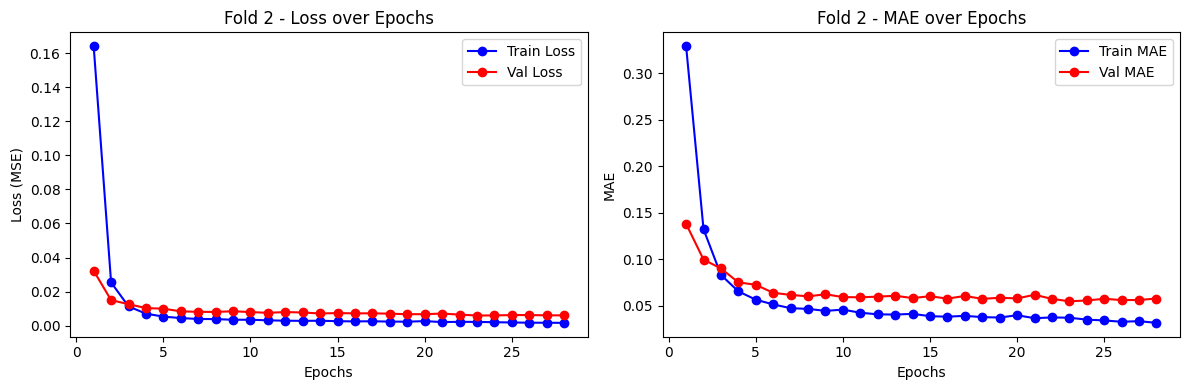

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Fold 2 - MSE: 0.006, R²: 0.832, RMSE: 0.077, MAE: 0.055
Training fold 3 ...
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.6860 - mae: 0.7592 - val_loss: 0.0199 - val_mae: 0.1144
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0225 - mae: 0.1196 - val_loss: 0.0096 - val_mae: 0.0765
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0104 - mae: 0.0830 - val_loss: 0.0061 - val_mae: 0.0604
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0072 - mae: 0.0619 - val_loss: 0.0046 - val_mae: 0.0525
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0066 - mae: 0.0576 - val_loss: 0.0043 - val_mae: 0.0498
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0057 - mae: 0.0542 - val_loss: 0.0041 - val_mae: 0.0485
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - mae: 0.0475 - val_loss: 0.0036 - val_mae: 0.0475
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0056 - mae: 0

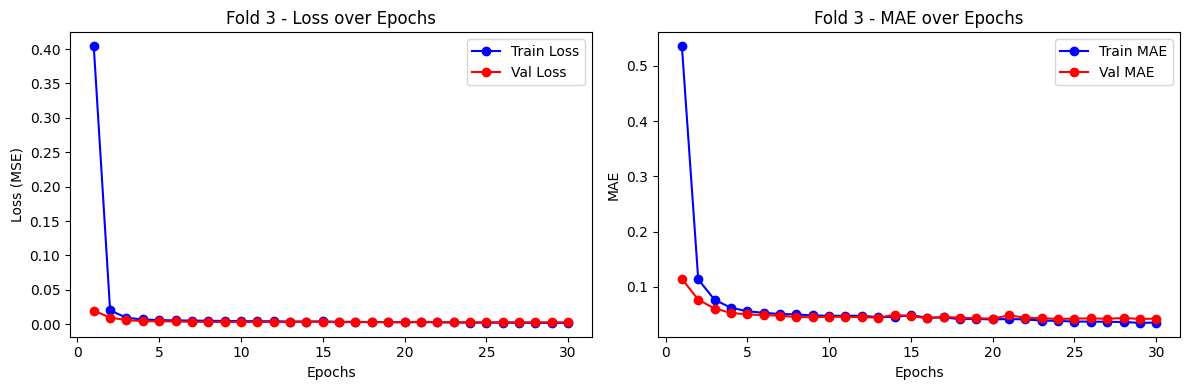

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Fold 3 - MSE: 0.003, R²: 0.940, RMSE: 0.053, MAE: 0.042
Training fold 4 ...
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2756 - mae: 0.4618 - val_loss: 0.0320 - val_mae: 0.1302
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0261 - mae: 0.1180 - val_loss: 0.0108 - val_mae: 0.0803
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0093 - mae: 0.0777 - val_loss: 0.0062 - val_mae: 0.0603
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0064 - mae: 0.0614 - val_loss: 0.0057 - val_mae: 0.0593
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0050 - mae: 0.0542 - val_loss: 0.0048 - val_mae: 0.0510
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041 - mae: 0.0472 - val_loss: 0.0050 - val_mae: 0.0530
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0044 - mae: 0.0473 - val_loss: 0.0045 - val_mae: 0.0496
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0053 - mae: 0

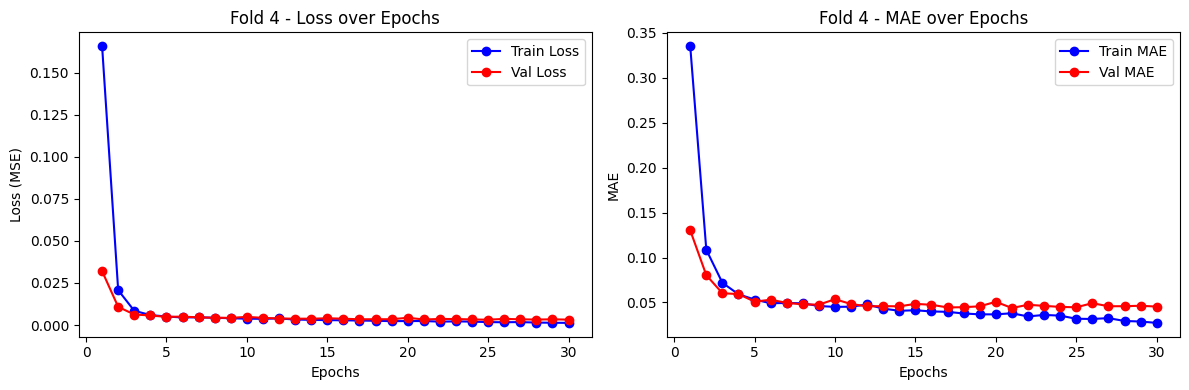

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Fold 4 - MSE: 0.003, R²: 0.933, RMSE: 0.056, MAE: 0.045
Training fold 5 ...
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3635 - mae: 0.5269 - val_loss: 0.0453 - val_mae: 0.1684
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0390 - mae: 0.1569 - val_loss: 0.0233 - val_mae: 0.1315
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0155 - mae: 0.1032 - val_loss: 0.0112 - val_mae: 0.0871
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0073 - mae: 0.0665 - val_loss: 0.0071 - val_mae: 0.0663
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0058 - mae: 0.0594 - val_loss: 0.0058 - val_mae: 0.0578
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 - mae: 0.0528 - val_loss: 0.0053 - val_mae: 0.0561
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0048 - mae: 0.0488 - val_loss: 0.0057 - val_mae: 0.0602
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 - mae: 0

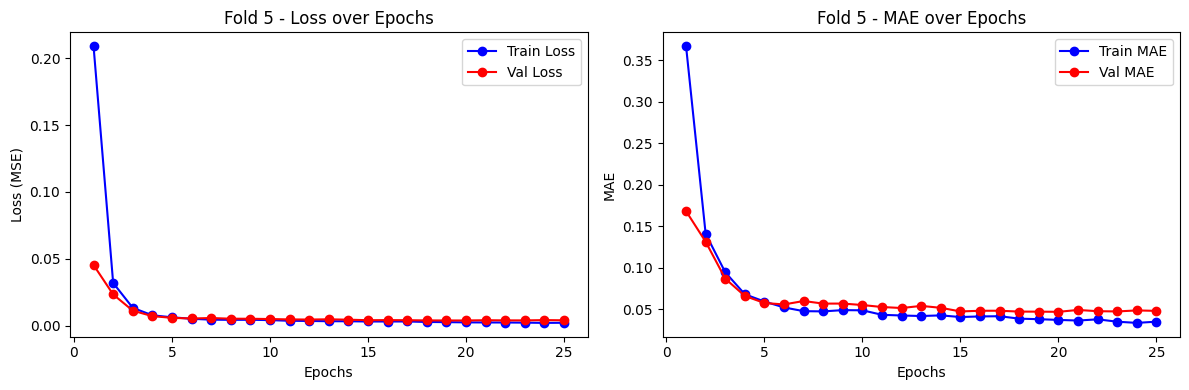

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Fold 5 - MSE: 0.004, R²: 0.927, RMSE: 0.062, MAE: 0.047


In [61]:
for train_index, val_index in kf.split(X_text):
    print(f"Training fold {fold} ...")

    # Split data for the current fold
    X_text_train_cv, X_text_val_cv = X_text[train_index], X_text[val_index]
    X_struct_train_cv, X_struct_val_cv = X_struct[train_index], X_struct[val_index]
    y_train_cv, y_val_cv = y[train_index], y[val_index]

    # Build the model using the best hyperparameters (from previous tuning)
    model = build_fusion_model(best_hp)

    # Use early stopping to prevent overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Train the model for this fold
    history = model.fit(
        {'text_input': X_text_train_cv, 'structured_input': X_struct_train_cv},
        y_train_cv,
        epochs=30,
        batch_size=8,
        validation_data=({'text_input': X_text_val_cv, 'structured_input': X_struct_val_cv}, y_val_cv),
        callbacks=[early_stop],
        verbose=1
    )

    # Plot learning curves for this fold to check for overfitting
    plot_learning_curves(history, fold)

    # Evaluate the model on the validation set
    y_val_pred = model.predict({'text_input': X_text_val_cv, 'structured_input': X_struct_val_cv}).flatten()

    fold_mse = mean_squared_error(y_val_cv, y_val_pred)
    fold_r2 = r2_score(y_val_cv, y_val_pred)
    fold_rmse = np.sqrt(fold_mse)
    fold_mae = mean_absolute_error(y_val_cv, y_val_pred)

    mse_list.append(fold_mse)
    r2_list.append(fold_r2)
    rmse_list.append(fold_rmse)
    mae_list.append(fold_mae)

    print(f"Fold {fold} - MSE: {fold_mse:.3f}, R²: {fold_r2:.3f}, RMSE: {fold_rmse:.3f}, MAE: {fold_mae:.3f}")

    all_actual.extend(y_val_cv)
    all_pred.extend(y_val_pred)

    fold += 1

In [62]:

# Compute average metrics across folds
avg_mse = np.mean(mse_list)
avg_r2 = np.mean(r2_list)
avg_rmse = np.mean(rmse_list)
avg_mae = np.mean(mae_list)

print("Cross-validation results:")
print(f"Average MSE: {avg_mse:.3f}")
print(f"Average R²: {avg_r2:.3f}")
print(f"Average RMSE: {avg_rmse:.3f}")
print(f"Average MAE: {avg_mae:.3f}")


Cross-validation results:
Average MSE: 0.004
Average R²: 0.905
Average RMSE: 0.063
Average MAE: 0.048


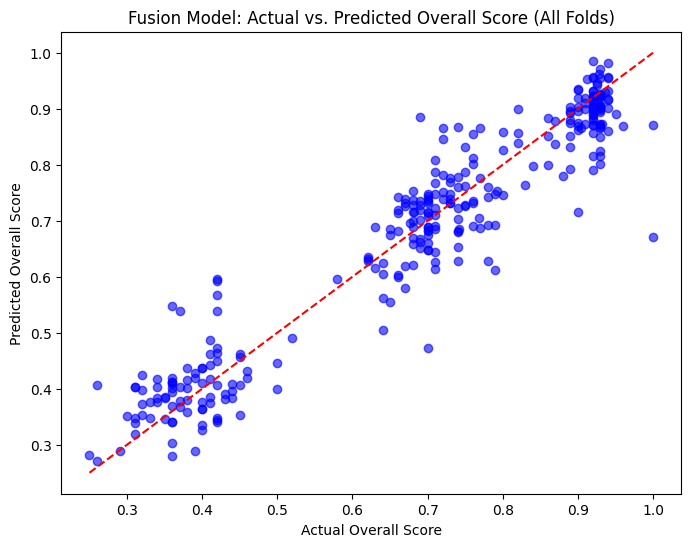

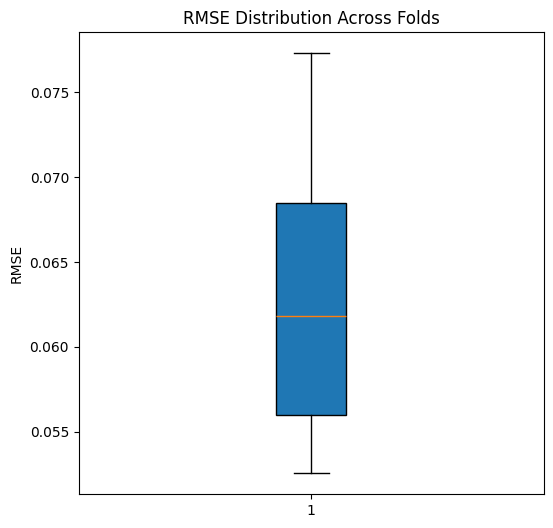

In [63]:
# Scatter plot: Actual vs. Predicted Overall Scores across all folds
plt.figure(figsize=(8, 6))
plt.scatter(all_actual, all_pred, alpha=0.6, color='blue')
plt.xlabel("Actual Overall Score")
plt.ylabel("Predicted Overall Score")
plt.title("Fusion Model: Actual vs. Predicted Overall Score (All Folds)")
plt.plot([min(all_actual), max(all_actual)], [min(all_actual), max(all_actual)], color='red', linestyle='--')  # Diagonal reference
plt.show()

# Boxplot of RMSE across folds to see variability
plt.figure(figsize=(6, 6))
plt.boxplot(rmse_list, patch_artist=True)
plt.ylabel("RMSE")
plt.title("RMSE Distribution Across Folds")
plt.show()